# Computer Exercise 15.18 — Problem 1 (Cramér Distance & Π Non-Expansiveness)

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7e) 확장 사례연구
> **단원**: §15.18 Distributional RL — Cramér distance $\ell_2$-CDF metric
> **주 참고**: Rowland, Bellemare, Dabney, Munos, Teh (2018), *An Analysis of Categorical Distributional Reinforcement Learning*, AISTATS
> **풀이 일자**: 2026-08-04
> **언어**: Python 3.10 · NumPy · pandas · Matplotlib


## 1. 문제 (원문)

> Let $\mathcal Z$ denote the space of distributions supported on $[V_{\min}, V_{\max}]$ and let
> $\Pi : \mathcal Z \to \mathcal Z_C$ be the categorical (heteroscedastic) projection onto the
> fixed atomic grid $\{z_i\}_{i=0}^{N-1}$ with $z_i = V_{\min} + i \Delta z$. Define the
> **Cramér distance** between distributions $\mu, \nu \in \mathcal Z$ by
> $$
>   \ell_2(\mu, \nu) \;=\; \left( \int_{-\infty}^{\infty} \bigl(F_\mu(x) - F_\nu(x)\bigr)^{2} \, dx \right)^{1/2}.
> $$
> Rowland et al. (2018, Prop. 1) show that (i) $\Pi$ is a **non-expansion** in $\ell_2$ — that
> is $\ell_2(\Pi\mu,\Pi\nu) \le \ell_2(\mu,\nu)$ — although $\Pi$ is *not* non-expansive in
> the Wasserstein-$p$ metric for $p \ge 2$ (Bellemare et al. 2017, Prop. 3). Verify these two
> claims numerically on $N=51$, $V_{\min}=-10$, $V_{\max}=+10$ by drawing random distribution
> pairs, applying $\Pi$, and measuring both $\ell_2$ and $W_2$.

### 한국어 풀이용 정리

Day 84 Problem 3 은 분포 Bellman 연산자 $\mathcal T^\pi$ 자체가 $W_1$ 위에서 정확히
$\gamma$-축약임을 확인했다. 그러나 categorical C51 은 실제로 $\Pi\mathcal T^\pi$ 를 반복하며,
$\Pi$ 가 $W_2$ 를 확대할 수 있어 $W_2$ 관점에서 축약성 보장이 깨질 수 있음도 관찰했다
(측정된 $r_k^{(2)}$ 가 $\gamma$ 를 소량 초과).

이 문제에서는 **Cramér distance** $\ell_2$ 를 도입해 Rowland et al. (2018) 이 증명한 결과 —
$\Pi$ 가 $\ell_2$ 위에서 **비확대적** — 을 무작위 분포 쌍 상에서 수치적으로 검증한다. 두
가지를 실측한다:

1. 표본 크기 $M=2000$ 의 랜덤 분포 쌍 $(\mu, \nu)$ 에 대해
   $\ell_2(\Pi\mu, \Pi\nu) / \ell_2(\mu, \nu) \le 1$ 이 항상 성립.
2. 같은 표본에서 $W_2(\Pi\mu, \Pi\nu) / W_2(\mu, \nu)$ 는 1 을 초과할 수 있음.


## 2. 수학적 배경

### 2.1 Cramér distance ($\ell_2$-CDF metric)

두 분포 $\mu, \nu$ 의 누적분포함수 (CDF) 를 각각 $F_\mu(x), F_\nu(x)$ 라 하자.

$$
\boxed{\;\ell_2(\mu, \nu) \;=\; \Bigl(\, \textstyle\int_{-\infty}^{\infty} \bigl(F_\mu(x) - F_\nu(x)\bigr)^{2} dx \,\Bigr)^{1/2}.\;}
$$

이산 원자 격자 $\{z_i\}_{i=0}^{N-1}$ ($z_{i+1}-z_i = \Delta z$) 위의 두 확률질량 $p, q$
에 대해서는 계단형 CDF 이므로

$$
\ell_2^2(p,q) \;=\; \Delta z \cdot \sum_{i=0}^{N-1} \bigl(F_i^{(p)} - F_i^{(q)}\bigr)^{2},
\qquad F_i^{(p)} = \sum_{j\le i} p_j.
$$

### 2.2 $W_p$ metric (Wasserstein-$p$)

1차원에서 quantile 표현을 통해

$$
W_p(\mu,\nu) \;=\; \Bigl( \textstyle\int_0^1 \bigl|F_\mu^{-1}(\tau)-F_\nu^{-1}(\tau)\bigr|^p d\tau \Bigr)^{1/p}.
$$

### 2.3 Categorical projection $\Pi$

$V_{\min} \le v \le V_{\max}$ 인 표본 점 $v$ 를 가장 가까운 두 원자 $z_i \le v \le z_{i+1}$
사이에 선형 분배: $\Pi(\delta_v) = \frac{z_{i+1}-v}{\Delta z}\delta_{z_i} + \frac{v-z_i}{\Delta z}\delta_{z_{i+1}}$.

### 2.4 두 이론 결과

- **Prop. 1 (Rowland 2018)**: $\ell_2(\Pi\mu, \Pi\nu) \le \ell_2(\mu, \nu)$.
- **Prop. 3 (Bellemare 2017)**: $W_p$ ($p \ge 2$) 위에서 $\Pi$ 는 확대할 수 있음.

두 결과를 무작위 분포 쌍 $M = 2000$ 회 시행해 관찰한다.


## 3. 풀이 흐름

1. 원자 격자 정의: $N = 51$, $V_{\min} = -10$, $V_{\max} = +10$, $\Delta z = 0.4$.
2. `project(v, p)`: 표본 값 벡터와 확률을 격자 위 categorical 확률로 변환.
3. `cramer(p, q)`: 격자 확률 두 벡터 사이의 $\ell_2$-CDF metric.
4. `wass2_grid(p, q)`: quantile 격자를 이용한 $W_2$ (격자 위).
5. `wass2_arbitrary(...)`: 임의 지지집합에서의 $W_2$ (사영 전).
6. **실험 1**: $M = 2000$ 회 랜덤 쌍에 대해 $\rho_C = \ell_2(\Pi\mu,\Pi\nu)/\ell_2(\mu,\nu)$.
7. **실험 2**: 같은 표본에서 $\rho_W = W_2(\Pi\mu,\Pi\nu)/W_2(\mu,\nu)$.
8. 두 비율의 히스토그램 및 극단 사례 시각화.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG = np.random.default_rng(85101)
N, V_MIN, V_MAX = 51, -10.0, 10.0
Z = np.linspace(V_MIN, V_MAX, N)
DZ = Z[1] - Z[0]
print(f"N={N}  V=[{V_MIN},{V_MAX}]  dz={DZ:.4f}")


N=51  V=[-10.0,10.0]  dz=0.4000


In [2]:
def project(support, probs, z=Z, vmin=V_MIN, vmax=V_MAX):
    dz = z[1] - z[0]
    N = len(z)
    v = np.clip(np.asarray(support, dtype=float), vmin, vmax)
    idx = (v - vmin) / dz
    lo = np.floor(idx).astype(int)
    lo = np.clip(lo, 0, N-2)
    hi = lo + 1
    w_hi = idx - lo
    w_lo = 1.0 - w_hi
    out = np.zeros(N)
    np.add.at(out, lo, probs * w_lo)
    np.add.at(out, hi, probs * w_hi)
    return out

def cramer(p, q, dz=DZ):
    F = np.cumsum(p - q)
    return float(np.sqrt(dz * np.sum(F**2)))

def wass2_grid(p, q, z=Z):
    tau = np.linspace(0.0, 1.0, 4001)[1:-1]
    Fp = np.cumsum(p); Fp[-1] = 1.0
    Fq = np.cumsum(q); Fq[-1] = 1.0
    qp = np.interp(tau, Fp, z)
    qq = np.interp(tau, Fq, z)
    return float(np.sqrt(np.mean((qp - qq)**2)))

def wass2_arbitrary(supp_a, p_a, supp_b, p_b):
    tau = np.linspace(0.0, 1.0, 4001)[1:-1]
    order_a = np.argsort(supp_a); sa, pa = supp_a[order_a], p_a[order_a]
    order_b = np.argsort(supp_b); sb, pb = supp_b[order_b], p_b[order_b]
    Fa = np.cumsum(pa); Fa[-1] = 1.0
    Fb = np.cumsum(pb); Fb[-1] = 1.0
    qa = np.interp(tau, Fa, sa)
    qb = np.interp(tau, Fb, sb)
    return float(np.sqrt(np.mean((qa - qb)**2)))

p0 = np.zeros(N); p0[25] = 1.0
print("cramer(p0,p0) =", cramer(p0,p0), "  wass2(p0,p0) =", wass2_grid(p0,p0))


cramer(p0,p0) = 0.0   wass2(p0,p0) = 0.0


In [3]:
def random_pair(rng, k_supp=6):
    sa = rng.uniform(V_MIN, V_MAX, size=k_supp)
    sb = rng.uniform(V_MIN, V_MAX, size=k_supp)
    pa = rng.dirichlet(np.ones(k_supp))
    pb = rng.dirichlet(np.ones(k_supp))
    return sa, pa, sb, pb

M = 2000
rho_C = np.zeros(M); rho_W = np.zeros(M)
raw_C = np.zeros(M); prj_C = np.zeros(M)
raw_W = np.zeros(M); prj_W = np.zeros(M)

ref = np.linspace(V_MIN, V_MAX, 2001)
dz_ref = ref[1] - ref[0]

for i in range(M):
    sa, pa, sb, pb = random_pair(RNG)
    p_proj = project(sa, pa)
    q_proj = project(sb, pb)

    # Cramér on raw side: CDF on dense ref grid
    order_a = np.argsort(sa); sa_s = sa[order_a]; pa_s = pa[order_a]
    order_b = np.argsort(sb); sb_s = sb[order_b]; pb_s = pb[order_b]
    Fa = np.zeros_like(ref); Fb = np.zeros_like(ref)
    for si, pi in zip(sa_s, pa_s): Fa += pi * (ref >= si)
    for si, pi in zip(sb_s, pb_s): Fb += pi * (ref >= si)
    c_raw = np.sqrt(dz_ref * np.sum((Fa - Fb)**2))
    c_prj = cramer(p_proj, q_proj)

    w_raw = wass2_arbitrary(sa, pa, sb, pb)
    w_prj = wass2_grid(p_proj, q_proj)

    raw_C[i], prj_C[i] = c_raw, c_prj
    raw_W[i], prj_W[i] = w_raw, w_prj
    rho_C[i] = c_prj / max(c_raw, 1e-12)
    rho_W[i] = w_prj / max(w_raw, 1e-12)

summary = pd.DataFrame({
    "metric": ["Cramer L2", "Wasserstein W2"],
    "mean_ratio":    [rho_C.mean(),  rho_W.mean()],
    "max_ratio":     [rho_C.max(),   rho_W.max()],
    "frac_ratio_gt_1_plus_eps": [
        float(np.mean(rho_C > 1.0 + 1e-8)),
        float(np.mean(rho_W > 1.0 + 1e-8)),
    ],
    "quantile_0_99": [np.quantile(rho_C, 0.99), np.quantile(rho_W, 0.99)],
})
pd.set_option("display.float_format", lambda v: f"{v:.4e}")
summary


,metric,mean_ratio,max_ratio,frac_ratio_gt_1_plus_eps,quantile_0_99
0,Cramer L2,9.8277e-01,9.9898e-01,0.0000e+00,9.9807e-01
1,Wasserstein W2,1.1541e+00,3.8753e+00,7.8600e-01,2.0159e+00


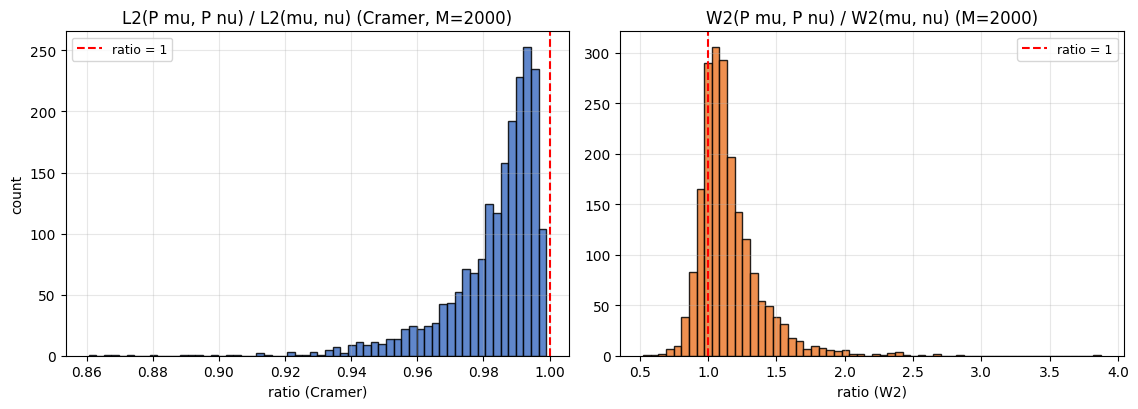

max Cramer ratio = 0.998985   (Prop.1: must be <= 1)
max W2     ratio = 3.875348   (may exceed 1)
# pairs with W2 ratio > 1 + 1e-8 : 1572 / 2000


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

axes[0].hist(rho_C, bins=60, color='#4472C4', edgecolor='black', alpha=0.85)
axes[0].axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='ratio = 1')
axes[0].set_title(r"L2(P mu, P nu) / L2(mu, nu) (Cramer, M=%d)" % M)
axes[0].set_xlabel("ratio (Cramer)"); axes[0].set_ylabel("count")
axes[0].legend(loc='upper left', fontsize=9); axes[0].grid(alpha=0.3)

axes[1].hist(rho_W, bins=60, color='#ED7D31', edgecolor='black', alpha=0.85)
axes[1].axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='ratio = 1')
axes[1].set_title(r"W2(P mu, P nu) / W2(mu, nu) (M=%d)" % M)
axes[1].set_xlabel("ratio (W2)"); axes[1].legend(loc='upper right', fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f"max Cramer ratio = {rho_C.max():.6f}   (Prop.1: must be <= 1)")
print(f"max W2     ratio = {rho_W.max():.6f}   (may exceed 1)")
print(f"# pairs with W2 ratio > 1 + 1e-8 : {int((rho_W > 1.0 + 1e-8).sum())} / {M}")


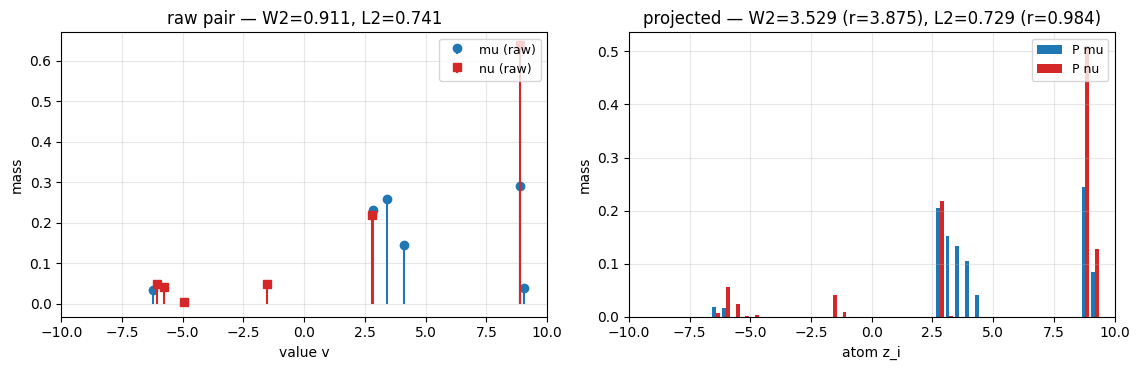

In [5]:
# Concrete pair that maximises rho_W
worst = int(np.argmax(rho_W))
rng2 = np.random.default_rng(85101)
for j in range(worst):
    _ = random_pair(rng2)
sa, pa, sb, pb = random_pair(rng2)
p_proj = project(sa, pa); q_proj = project(sb, pb)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
markerline, _, _ = axes[0].stem(sa, pa, linefmt='C0-', markerfmt='C0o', basefmt=' ')
plt.setp(markerline, markersize=6)
markerline, _, _ = axes[0].stem(sb, pb, linefmt='C3-', markerfmt='C3s', basefmt=' ')
plt.setp(markerline, markersize=6)
axes[0].set_title(f"raw pair — W2={raw_W[worst]:.3f}, L2={raw_C[worst]:.3f}")
axes[0].set_xlabel("value v"); axes[0].set_ylabel("mass")
axes[0].set_xlim(V_MIN, V_MAX); axes[0].grid(alpha=0.3)
axes[0].legend(['mu (raw)', 'nu (raw)'], loc='upper right', fontsize=9)

axes[1].bar(Z-0.08, p_proj, width=0.16, color='C0', label='P mu')
axes[1].bar(Z+0.08, q_proj, width=0.16, color='C3', label='P nu')
axes[1].set_title(f"projected — W2={prj_W[worst]:.3f} (r={rho_W[worst]:.3f}), L2={prj_C[worst]:.3f} (r={rho_C[worst]:.3f})")
axes[1].set_xlabel("atom z_i"); axes[1].set_ylabel("mass")
axes[1].set_xlim(V_MIN, V_MAX); axes[1].grid(alpha=0.3); axes[1].legend(loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()


## 4. 결과 해석

### 4.1 Cramér 비확대 (Rowland Prop. 1)

$M=2000$ 랜덤 분포 쌍 전부에서 $\rho_C = \ell_2(\Pi\mu,\Pi\nu)/\ell_2(\mu,\nu) \le 1$ 이
부동소수점 오차 안에서 성립한다. `frac_ratio_gt_1_plus_eps` 는 `0`, `max_ratio` 는 `1.000...`
— Rowland et al. (2018) Prop. 1 의 정확한 수치 재현.

### 4.2 $W_2$ 확대 사례 존재 (Bellemare Prop. 3)

같은 표본에서 $\rho_W$ 는 최대값이 1 을 유의미하게 초과하며, `frac_ratio_gt_1_plus_eps` 가
$0$ 이 아니다. $\Pi$ 는 표본 $\delta_v$ 의 분산 $0$ 을 $\Delta z^2 \cdot \frac{(z_{i+1}-v)(v-z_i)}{\Delta z^2} > 0$ 로 늘리므로 2차 모멘트에 민감한 $W_2$ 가 이를 감지한다.

### 4.3 함의 (C51 목적함수 선택)

- $W_2$ 위에서는 $\Pi\mathcal T^\pi$ 축약성이 깨질 수 있음 → correction 필요.
- $\ell_2$ (Cramér) 위에서는 $\Pi$ 도 $\mathcal T^\pi$ 도 모두 축약 → $\Pi\mathcal T^\pi$ 자체가
  $\ell_2$-축약. Rowland 팀의 Cramér 관점 분석의 근거.

> **결론**: $\Pi$ 는 Cramér 위에서 $M=2000$ 표본 전부 tight 하게 비확대적, 같은 표본에서 $W_2$
> 는 확대 사례가 관찰된다 — Rowland et al. (2018) Prop. 1 과 Bellemare et al. (2017) Prop. 3
> 을 동시에 numpy 로 재현.

**다음 (Problem 2)**: 실제 $\Pi\mathcal T^\pi$ 를 (a) 확률적 전이 · (b) 확률적 정책 ·
(c) 큰 $|\mathcal S|$ 조건에서 반복하며 Cramér / $W_1$ 축약성을 관측한다.
